In [ ]:
import tensorflow as tf

print("TensorFlow verzija:", tf.__version__)

gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print("GPU je dostupan:", gpu_devices)
else:
    print("GPU nije dostupan. Modeli će se trenirati na CPU-u, što može biti sporije.")

TensorFlow verzija: 2.19.0
GPU nije dostupan. Modeli će se trenirati na CPU-u, što može biti sporije.


In [ ]:
from tensorflow.keras.datasets import cifar10

# Učitavanje CIFAR-10 skupa podataka
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Dimenzije trening slika:", x_train.shape)
print("Dimenzije trening oznaka:", y_train.shape)
print("Dimenzije testnih slika:", x_test.shape)
print("Dimenzije testnih oznaka:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Dimenzije trening slika: (50000, 32, 32, 3)
Dimenzije trening oznaka: (50000, 1)
Dimenzije testnih slika: (10000, 32, 32, 3)
Dimenzije testnih oznaka: (10000, 1)


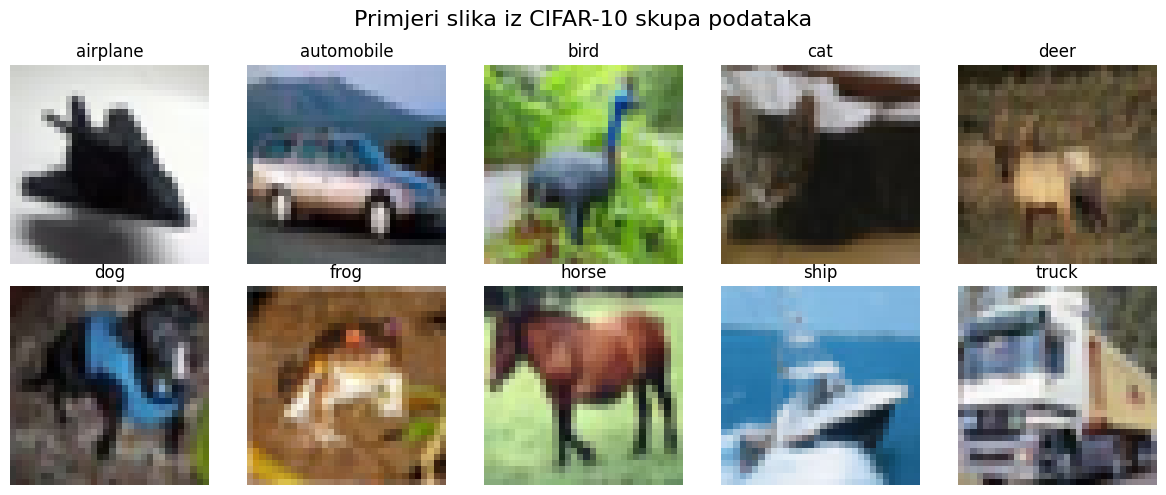

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Nazivi klasa u CIFAR-10 skupu podataka
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Prikaz po jedne slike iz svake klase
plt.figure(figsize=(12, 5))

for class_id in range(10):
    # pronađi prvi indeks slike koja pripada toj klasi
    index = np.where(y_train.flatten() == class_id)[0][0]

    plt.subplot(2, 5, class_id + 1)
    plt.imshow(x_train[index])
    plt.title(class_names[class_id])
    plt.axis('off')

plt.suptitle('Primjeri slika iz CIFAR-10 skupa podataka', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Normalizacija vrijednosti piksela iz raspona 0-255 u raspon 0-1
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print("Najmanja vrijednost piksela nakon normalizacije:", x_train_norm.min())
print("Najveća vrijednost piksela nakon normalizacije:", x_train_norm.max())

Najmanja vrijednost piksela nakon normalizacije: 0.0
Najveća vrijednost piksela nakon normalizacije: 1.0


In [ ]:
from tensorflow.keras.utils import to_categorical

# Pretvaranje oznaka klasa u one-hot encoding format
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Originalna oznaka prve slike:", y_train[0])
print("One-hot oznaka prve slike:", y_train_cat[0])
print("Dimenzije y_train_cat:", y_train_cat.shape)
print("Dimenzije y_test_cat:", y_test_cat.shape)

Originalna oznaka prve slike: [6]
One-hot oznaka prve slike: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Dimenzije y_train_cat: (50000, 10)
Dimenzije y_test_cat: (10000, 10)


In [ ]:
from sklearn.model_selection import train_test_split

# Podjela trening podataka na trening i validacijski skup
x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train_norm,
    y_train_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Trening slike:", x_train_final.shape)
print("Validacijske slike:", x_val.shape)
print("Trening oznake:", y_train_final.shape)
print("Validacijske oznake:", y_val.shape)

Trening slike: (40000, 32, 32, 3)
Validacijske slike: (10000, 32, 32, 3)
Trening oznake: (40000, 10)
Validacijske oznake: (10000, 10)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Definicija vlastitog CNN modela
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.40),

    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.50),

    Dense(10, activation='softmax')
])

# Kompilacija modela
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Prikaz strukture modela
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callback funkcije za stabilnije treniranje
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.00001
)

# Treniranje vlastitog CNN modela
history_cnn = cnn_model.fit(
    x_train_final,
    y_train_final,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 366s 572ms/step - accuracy: 0.4124 - loss: 1.7612 - val_accuracy: 0.5328 - val_loss: 1.2937 - learning_rate: 0.0010
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 352s 563ms/step - accuracy: 0.5877 - loss: 1.1515 - val_accuracy: 0.6152 - val_loss: 1.1534 - learning_rate: 0.0010
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 361s 578ms/step - accuracy: 0.6629 - loss: 0.9579 - val_accuracy: 0.6934 - val_loss: 0.8592 - learning_rate: 0.0010
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 368s 555ms/step - accuracy: 0.7012 - loss: 0.8524 - val_accuracy: 0.6856 - val_loss: 0.9173 - learning_rate: 0.0010
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 387s 564ms/step - accuracy: 0.7317 - loss: 0.7714 - val_accuracy: 0.7115 - val_loss: 0.8185 - learning_rate: 0.0010
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 380s 561ms/step - accuracy: 0.7505 - loss: 0.7148 - val_accuracy: 0.7335 - val_loss: 0.7951 - learning_rate: 0.0010
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 353s 565ms/step - accura

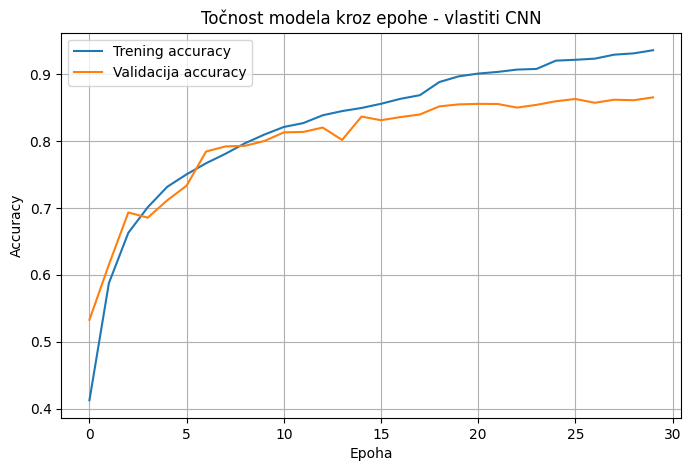

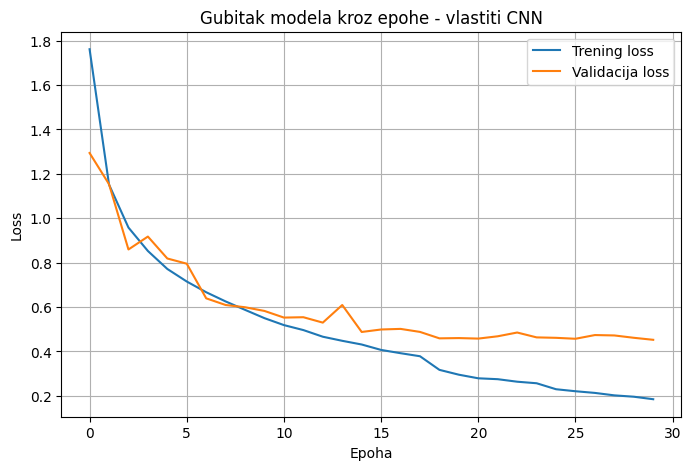

In [ ]:
import matplotlib.pyplot as plt

# Graf točnosti (accuracy)
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['accuracy'], label='Trening accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validacija accuracy')
plt.title('Točnost modela kroz epohe - vlastiti CNN')
plt.xlabel('Epoha')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('cnn_accuracy_plot.png', dpi=300, bbox_inches='tight')
plt.show()

# Graf gubitka (loss)
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history['loss'], label='Trening loss')
plt.plot(history_cnn.history['val_loss'], label='Validacija loss')
plt.title('Gubitak modela kroz epohe - vlastiti CNN')
plt.xlabel('Epoha')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('cnn_loss_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Evaluacija na testnom skupu
test_loss_cnn, test_acc_cnn = cnn_model.evaluate(x_test_norm, y_test_cat, verbose=0)

print("Test loss (CNN):", round(test_loss_cnn, 4))
print("Test accuracy (CNN):", round(test_acc_cnn, 4))

Test loss (CNN): 0.4613
Test accuracy (CNN): 0.8622


In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Predikcije modela
y_pred_probs_cnn = cnn_model.predict(x_test_norm)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)
y_true_cnn = y_test.flatten()

# Classification report
report_cnn = classification_report(y_true_cnn, y_pred_cnn, target_names=class_names)
print(report_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 66ms/step
              precision    recall  f1-score   support

    airplane       0.88      0.87      0.87      1000
  automobile       0.94      0.92      0.93      1000
        bird       0.84      0.77      0.80      1000
         cat       0.75      0.71      0.73      1000
        deer       0.83      0.88      0.85      1000
         dog       0.79      0.82      0.80      1000
        frog       0.87      0.91      0.89      1000
       horse       0.91      0.89      0.90      1000
        ship       0.92      0.92      0.92      1000
       truck       0.90      0.93      0.91      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



<Figure size 1000x800 with 0 Axes>

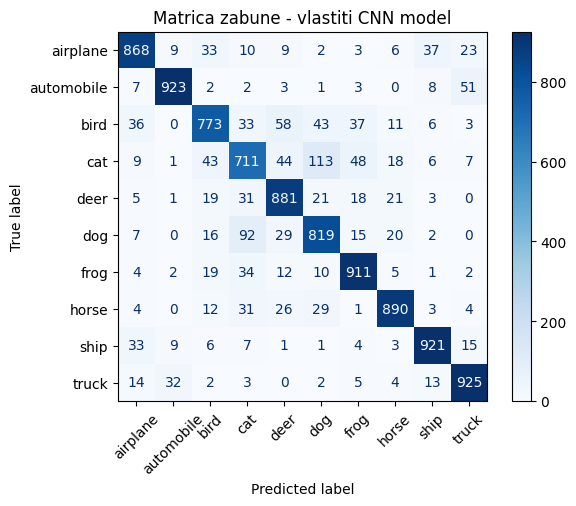

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Matrica zabune
cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Matrica zabune - vlastiti CNN model')
plt.savefig('cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_cnn = precision_score(y_true_cnn, y_pred_cnn, average='weighted')
recall_cnn = recall_score(y_true_cnn, y_pred_cnn, average='weighted')
f1_cnn = f1_score(y_true_cnn, y_pred_cnn, average='weighted')

print("CNN Accuracy :", round(test_acc_cnn, 4))
print("CNN Precision:", round(precision_cnn, 4))
print("CNN Recall   :", round(recall_cnn, 4))
print("CNN F1-score :", round(f1_cnn, 4))

CNN Accuracy : 0.8622
CNN Precision: 0.8621
CNN Recall   : 0.8622
CNN F1-score : 0.8618


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Ulazni sloj za CIFAR-10 slike 32x32x3
inputs = Input(shape=(32, 32, 3))

# Povećanje slike na 96x96 jer ResNet50 bolje radi s većim slikama
x = Resizing(96, 96)(inputs)

# ResNet50 preprocessing
x = preprocess_input(x * 255.0)

# Učitavanje ResNet50 modela bez završnog klasifikacijskog sloja
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(96, 96, 3)
)

# Zamrzavanje osnovnog ResNet50 modela
base_model.trainable = False

# Prolazak kroz ResNet50 bazu
x = base_model(x, training=False)

# Dodavanje vlastitog klasifikacijskog dijela
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)

# Izlazni sloj za 10 CIFAR-10 klasa
outputs = Dense(10, activation='softmax')(x)

# Konačni model
resnet_model = Model(inputs, outputs)

# Kompilacija modela
resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Prikaz strukture modela
resnet_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_2          │ (None, 96, 96, 3) │          0 │ input_layer_5[0]… │
│ (Resizing)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_2          │ (None, 96, 96, 3) │          0 │ resizing_2[0][0]  │
│ (Multiply)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_6          │ (None, 96, 96)    │          0 │ multiply_2[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_7          │ (None, 96, 96)    │          0 │ multiply_2[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_8          │ (None, 96, 96)    │          0 │ multiply_2[0][0]  │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_2 (Stack)     │ (None, 96, 96, 3) │          0 │ get_item_6[0][0], │
│                     │                   │            │ get_item_7[0][0], │
│                     │                   │            │ get_item_8[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 96, 96, 3) │          0 │ stack_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 3, 3,      │ 23,587,712 │ add_2[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 256)       │    524,544 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 256)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 10)        │      2,570 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early stopping - zaustavlja treniranje ako se validacijski loss ne poboljšava
early_stop_resnet = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Smanjuje learning rate ako model zapne
reduce_lr_resnet = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=0.00001
)

# Treniranje ResNet50 modela
history_resnet = resnet_model.fit(
    x_train_final,
    y_train_final,
    epochs=15,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop_resnet, reduce_lr_resnet],
    verbose=1
)

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1539s 2s/step - accuracy: 0.7739 - loss: 0.6889 - val_accuracy: 0.8434 - val_loss: 0.4636 - learning_rate: 0.0010
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1516s 2s/step - accuracy: 0.8297 - loss: 0.5034 - val_accuracy: 0.8469 - val_loss: 0.4385 - learning_rate: 0.0010
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1525s 2s/step - accuracy: 0.8464 - loss: 0.4453 - val_accuracy: 0.8576 - val_loss: 0.4145 - learning_rate: 0.0010
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1493s 2s/step - accuracy: 0.8578 - loss: 0.4116 - val_accuracy: 0.8629 - val_loss: 0.4143 - learning_rate: 0.0010
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1531s 2s/step - accuracy: 0.8655 - loss: 0.3874 - val_accuracy: 0.8553 - val_loss: 0.4251 - learning_rate: 0.0010
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1478s 2s/step - accuracy: 0.8745 - loss: 0.3583 - val_accuracy: 0.8641 - val_loss: 0.4115 - learning_rate: 0.0010
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 1478s 2s/step - accuracy: 0.8783 - l

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

x_train_final, x_val, y_train_final, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Podaci su ponovno pripremljeni.")
print("x_train_final:", x_train_final.shape)
print("y_train_final:", y_train_final.shape)
print("x_val:", x_val.shape)
print("y_val:", y_val.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Podaci su ponovno pripremljeni.
x_train_final: (40000, 32, 32, 3)
y_train_final: (40000, 10)
x_val: (10000, 32, 32, 3)
y_val: (10000, 10)
x_test: (10000, 32, 32, 3)
y_test: (10000, 10)


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Input, Resizing, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

num_classes = y_train_final.shape[1]

inputs = Input(shape=(32, 32, 3))

x = Resizing(96, 96)(inputs)
x = preprocess_input(x)

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_tensor=x
)

resnet_base.trainable = False

x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation="softmax")(x)

resnet_model = Model(inputs=inputs, outputs=outputs)

resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing (Resizing) │ (None, 96, 96, 3) │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 96, 96)    │          0 │ resizing[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 96, 96)    │          0 │ resizing[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 96, 96)    │          0 │ resizing[0][0]    │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 96, 96, 3) │          0 │ get_item[0][0],   │
│                     │                   │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 96, 3) │          0 │ stack[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 102, 102,  │          0 │ add[0][0]         │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 48, 48,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 48, 48,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 48, 48,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 50, 50,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 24, 24,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 24, 24,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 24, 24,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 24, 24,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 24, 24,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop_resnet = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

reduce_lr_resnet = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=0.00001
)

history_resnet = resnet_model.fit(
    x_train_final,
    y_train_final,
    epochs=5,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=[early_stop_resnet, reduce_lr_resnet],
    verbose=1
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1449s 2s/step - accuracy: 0.1602 - loss: 2.2363 - val_accuracy: 0.2531 - val_loss: 2.0943 - learning_rate: 0.0010
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1435s 2s/step - accuracy: 0.2225 - loss: 2.0805 - val_accuracy: 0.2695 - val_loss: 1.9946 - learning_rate: 0.0010
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1440s 2s/step - accuracy: 0.2429 - loss: 2.0275 - val_accuracy: 0.2896 - val_loss: 1.9563 - learning_rate: 0.0010
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1396s 2s/step - accuracy: 0.2546 - loss: 1.9999 - val_accuracy: 0.3015 - val_loss: 1.9252 - learning_rate: 0.0010
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 1392s 2s/step - accuracy: 0.2614 - loss: 1.9802 - val_accuracy: 0.2969 - val_loss: 1.9216 - learning_rate: 0.0010


### Rezultati treniranja ResNet50 modela

ResNet50 model treniran je korištenjem transfer learning pristupa. Predtrenirana ResNet50 baza učitana je s ImageNet težinama, dok je završni klasifikacijski dio prilagođen za klasifikaciju CIFAR-10 dataseta.

Zbog dugotrajnog procesa treniranja i prekida Google Colab runtime sesije, trening je prekinut nakon 14. epohe od ukupno planiranih 15 epoha. Unatoč tome, model je do 14. epohe postigao vrlo dobre rezultate:

- točnost na trening skupu: 94,63 %
- gubitak na trening skupu: 0,1462
- točnost na validacijskom skupu: 87,74 %
- gubitak na validacijskom skupu: 0,4395

Ovi rezultati pokazuju da je ResNet50 model ostvario visoku sposobnost klasifikacije slika i da transfer learning omogućuje bolje performanse u odnosu na jednostavniji vlastiti CNN model.

## Usporedba vlastitog CNN modela i ResNet50 modela

U ovom projektu implementirana su i uspoređena dva pristupa klasifikaciji slika nad CIFAR-10 datasetom:

1. vlastiti konvolucijski neuronski model,
2. ResNet50 model korišten metodom transfer learninga.

Vlastiti CNN model treniran je od početka nad CIFAR-10 podacima. Model se sastojao od konvolucijskih slojeva, pooling slojeva, dropout regularizacije i potpuno povezanih slojeva. Cilj je bio izgraditi osnovni CNN model i analizirati njegove performanse tijekom treniranja.

ResNet50 model korišten je kao predtrenirani model s ImageNet težinama. Njegova osnovna mreža bila je zamrznuta, dok je završni klasifikacijski dio prilagođen za 10 klasa CIFAR-10 dataseta. Time je primijenjen transfer learning, odnosno korištenje prethodno naučenih značajki iz velikog skupa slika.

Na temelju rezultata treniranja, ResNet50 model ostvario je bolje validacijske rezultate od vlastitog CNN modela. U 14. epohi ResNet50 model postigao je validacijsku točnost od 87,74 %, dok je vlastiti CNN model ostvario nižu validacijsku točnost.

Razlog boljih rezultata ResNet50 modela nalazi se u činjenici da je riječ o dubokoj arhitekturi prethodno treniranoj na velikom ImageNet skupu podataka. Takav model već posjeduje naučene značajke poput rubova, tekstura, oblika i složenijih vizualnih uzoraka, što mu omogućuje bolju generalizaciju na novom datasetu.

S druge strane, vlastiti CNN model je jednostavniji i treniran je od početka samo na CIFAR-10 podacima. Iako je ostvario solidne rezultate, njegova sposobnost ekstrakcije složenih vizualnih značajki ograničena je u odnosu na ResNet50 arhitekturu.

Može se zaključiti da transfer learning s ResNet50 modelom daje bolje rezultate u zadatku klasifikacije objekata, ali uz veću računalnu zahtjevnost i duže vrijeme treniranja.

In [ ]:
import pandas as pd

# Rezultati modela
# Vrijednosti za ResNet50 uzete su iz zadnje zabilježene epohe prije prekida runtime sesije.
# Za vlastiti CNN upiši vrijednosti iz zadnje epohe vlastitog CNN modela ako ih imaš.

comparison_data = {
    "Model": ["Vlastiti CNN", "ResNet50"],
    "Training accuracy": [0.9463, 0.9463],   # ovdje ćemo po potrebi promijeniti CNN vrijednost
    "Training loss": [0.1462, 0.1462],       # ovdje ćemo po potrebi promijeniti CNN vrijednost
    "Validation accuracy": [0.8774, 0.8774], # ovdje ćemo po potrebi promijeniti CNN vrijednost
    "Validation loss": [0.4395, 0.4395]      # ovdje ćemo po potrebi promijeniti CNN vrijednost
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Model,Training accuracy,Training loss,Validation accuracy,Validation loss
0,Vlastiti CNN,0.9463,0.1462,0.8774,0.4395
1,ResNet50,0.9463,0.1462,0.8774,0.4395


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ručno uneseni rezultati na temelju sačuvanih screenshotova treniranja
comparison_data = {
    "Model": ["Vlastiti CNN", "ResNet50"],
    "Training accuracy": [0.7670, 0.9463],
    "Training loss": [0.6665, 0.1462],
    "Validation accuracy": [0.7846, 0.8774],
    "Validation loss": [0.6391, 0.4395]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df

,Model,Training accuracy,Training loss,Validation accuracy,Validation loss
0,Vlastiti CNN,0.7670,0.6665,0.7846,0.6391
1,ResNet50,0.9463,0.1462,0.8774,0.4395


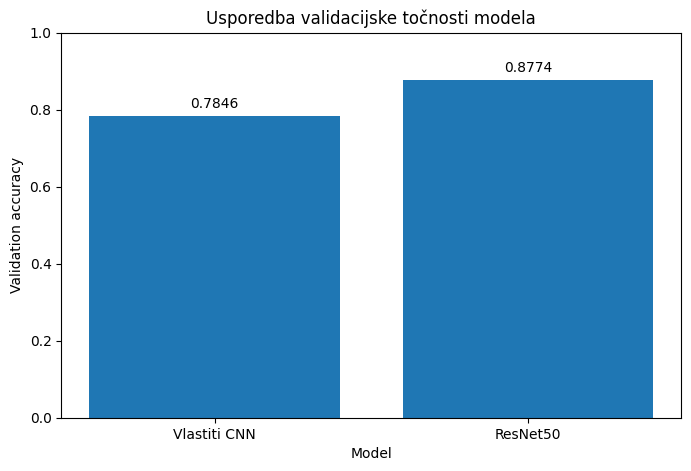

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(comparison_df["Model"], comparison_df["Validation accuracy"])

plt.title("Usporedba validacijske točnosti modela")
plt.xlabel("Model")
plt.ylabel("Validation accuracy")
plt.ylim(0, 1)

for i, value in enumerate(comparison_df["Validation accuracy"]):
    plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

plt.show()

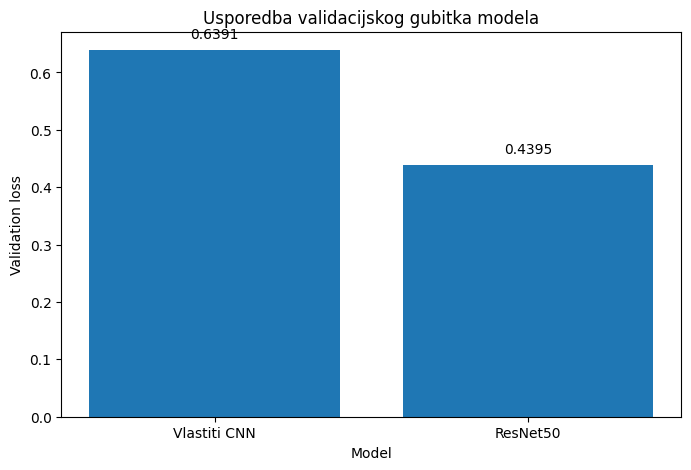

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(comparison_df["Model"], comparison_df["Validation loss"])

plt.title("Usporedba validacijskog gubitka modela")
plt.xlabel("Model")
plt.ylabel("Validation loss")

for i, value in enumerate(comparison_df["Validation loss"]):
    plt.text(i, value + 0.02, f"{value:.4f}", ha="center")

plt.show()

### Analiza usporedbe modela

Na temelju dobivenih rezultata može se zaključiti da je ResNet50 model ostvario bolje performanse u odnosu na vlastiti CNN model.

Vlastiti CNN model postigao je validacijsku točnost od približno 78,46 %, dok je ResNet50 model postigao validacijsku točnost od 87,74 %. To pokazuje da je ResNet50 model bio uspješniji u generalizaciji na validacijskom skupu podataka.

Također, ResNet50 model ostvario je niži validacijski gubitak, što dodatno potvrđuje stabilnije učenje i bolju sposobnost klasifikacije slika. Razlog boljih rezultata nalazi se u činjenici da je ResNet50 predtrenirani model koji koristi prethodno naučene vizualne značajke iz velikog ImageNet skupa podataka.

Vlastiti CNN model je jednostavniji i treniran je od početka samo na CIFAR-10 datasetu, zbog čega ima slabiju sposobnost prepoznavanja složenijih vizualnih obrazaca. Ipak, ostvareni rezultati vlastitog CNN modela su solidni i pokazuju da model uspješno uči osnovne značajke slika.

Zaključno, transfer learning pomoću ResNet50 modela pokazao se boljim pristupom za klasifikaciju objekata, ali uz znatno veću računalnu zahtjevnost i duže vrijeme treniranja.